In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
import re
import string


In [ ]:
data_fake=pd.read_csv('Fake.csv')
data_true=pd.read_csv('True.csv')

In [ ]:
from google.colab import drive
drive.mount('drive')

Drive already mounted at drive; to attempt to forcibly remount, call drive.mount("drive", force_remount=True).


In [ ]:
data_fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [ ]:
data_true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [ ]:
data_fake["class"]=0
data_true['class']=1

In [ ]:
data_fake.shape,data_true.shape

((23481, 5), (21417, 5))

In [ ]:
data_fake_manual_testing = data_fake.tail(10)
data_fake.drop(data_fake_manual_testing.index, axis=0, inplace=True)

data_true_manual_testing = data_true.tail(10)
data_true.drop(data_true_manual_testing.index, axis=0, inplace=True)

In [ ]:
data_merge = pd.concat([data_fake, data_true], axis=0)
display(data_merge.head())

,title,text,subject,date,class
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


Next, we'll drop columns that are not relevant for the classification task, such as 'title', 'subject', and 'date'. The 'text' column will be our primary feature.

In [ ]:
data = data_merge.drop(['title', 'subject', 'date'], axis=1)
display(data.head())

,text,class
0,Donald Trump just couldn t wish all Americans ...,0
1,House Intelligence Committee Chairman Devin Nu...,0
2,"On Friday, it was revealed that former Milwauk...",0
3,"On Christmas day, Donald Trump announced that ...",0
4,Pope Francis used his annual Christmas Day mes...,0


In [ ]:
data_fake.shape,data_true.shape

((23471, 5), (21407, 5))

In [ ]:
data_fake_manual_testing.loc[:, 'class'] = 0
data_true_manual_testing.loc[:, 'class'] = 1

In [ ]:
data_fake_manual_testing.head(10)

,title,text,subject,date,class
23471,Seven Iranians freed in the prisoner swap have...,"21st Century Wire says This week, the historic...",Middle-east,"January 20, 2016",0
23472,#Hashtag Hell & The Fake Left,By Dady Chery and Gilbert MercierAll writers ...,Middle-east,"January 19, 2016",0
23473,Astroturfing: Journalist Reveals Brainwashing ...,Vic Bishop Waking TimesOur reality is carefull...,Middle-east,"January 19, 2016",0
23474,The New American Century: An Era of Fraud,Paul Craig RobertsIn the last years of the 20t...,Middle-east,"January 19, 2016",0
23475,Hillary Clinton: ‘Israel First’ (and no peace ...,Robert Fantina CounterpunchAlthough the United...,Middle-east,"January 18, 2016",0
23476,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016",0
23477,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016",0
23478,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016",0
23479,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016",0
23480,10 U.S. Navy Sailors Held by Iranian Military ...,21st Century Wire says As 21WIRE predicted in ...,Middle-east,"January 12, 2016",0


In [ ]:
data_merge = pd.concat([data_fake, data_true], axis =0 )
data_merge.head(10)

,title,text,subject,date,class
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0
5,Racist Alabama Cops Brutalize Black Boy While...,The number of cases of cops brutalizing and ki...,News,"December 25, 2017",0
6,"Fresh Off The Golf Course, Trump Lashes Out A...",Donald Trump spent a good portion of his day a...,News,"December 23, 2017",0
7,Trump Said Some INSANELY Racist Stuff Inside ...,In the wake of yet another court decision that...,News,"December 23, 2017",0
8,Former CIA Director Slams Trump Over UN Bully...,Many people have raised the alarm regarding th...,News,"December 22, 2017",0
9,WATCH: Brand-New Pro-Trump Ad Features So Muc...,Just when you might have thought we d get a br...,News,"December 21, 2017",0


In [ ]:
data_merge.columns

Index(['title', 'text', 'subject', 'date', 'class'], dtype='object')

In [ ]:
data = data_merge.drop(['title', 'subject','date'], axis = 1)

In [ ]:
data.isnull().sum()

,0
level_0,0
text,0
class,0


In [ ]:
data= data.sample(frac=1)

In [ ]:
data.head()

,text,class
2032,It was bound to happen as soon as House Inte...,0
11567,Watch Joy Behar as she hilariously attempts to...,0
20105,LISBON (Reuters) - The number of foreign touri...,1
19383,TOKYO (Reuters) - A court in Japan on Friday o...,1
6347,Twitter is presumptive presidential nominee Do...,0


### Class Distribution
Let's visualize the distribution of `Fake` vs. `True` news in our combined dataset.

/tmp/ipykernel_1745/919525110.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='class', data=data, palette='viridis')


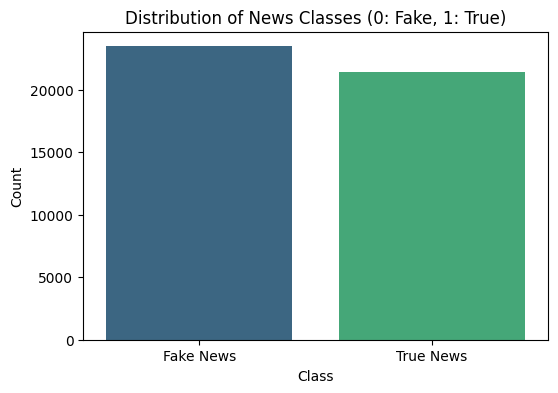

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='class', data=data, palette='viridis')
plt.title('Distribution of News Classes (0: Fake, 1: True)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks([0, 1], ['Fake News', 'True News'])
plt.show()

In [ ]:
data.reset_index(inplace= True)
data.drop(['index'], axis=1,inplace=True)

In [ ]:
data.columns

Index(['level_0', 'text', 'class'], dtype='object')

In [ ]:
data.head()

,level_0,text,class
0,0,It was bound to happen as soon as House Inte...,0
1,1,Watch Joy Behar as she hilariously attempts to...,0
2,2,LISBON (Reuters) - The number of foreign touri...,1
3,3,TOKYO (Reuters) - A court in Japan on Friday o...,1
4,4,Twitter is presumptive presidential nominee Do...,0


In [ ]:
def wordopt(text):
    text = text.lower()
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r"\\W"," ",text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>+', '', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\n', '', text)
    text = re.sub(r'\w*\d\w*', '', text)
    return text

In [ ]:
data['text']= data['text'].apply(wordopt)

In [ ]:
x = data['text']
y = data['class']

In [ ]:
z_train, z_test, y_train, y_test = train_test_split(x, y, test_size=0.25)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorization = TfidfVectorizer()
xv_train = vectorization.fit_transform(z_train)
xv_test = vectorization.transform(z_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
LR = LogisticRegression()
LR.fit(xv_train,y_train)

In [ ]:
pred_lr=LR.predict(xv_test)

In [ ]:
LR.score(xv_test, y_test)

In [ ]:
print(classification_report(y_test, pred_lr))

### Confusion Matrix for Logistic Regression
Let's visualize the performance of the Logistic Regression model using a confusion matrix.

In [ ]:
from sklearn.metrics import confusion_matrix

cm_lr = confusion_matrix(y_test, pred_lr)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake News', 'True News'], yticklabels=['Fake News', 'True News'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier
DT = DecisionTreeClassifier()
DT.fit(xv_train, y_train)

In [ ]:
pred_dt = DT.predict(xv_test)

In [ ]:
DT.score(xv_test, y_test)

In [ ]:
print(classification_report(y_test, pred_dt))

### Confusion Matrix for Decision Tree
Now, let's visualize the performance of the Decision Tree model using a confusion matrix.

In [ ]:
cm_dt = confusion_matrix(y_test, pred_dt)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', xticklabels=['Fake News', 'True News'], yticklabels=['Fake News', 'True News'])
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
print([x for x in globals() if 'train'in x.lower()])

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
GBC = GradientBoostingClassifier(random_state=0)
GBC.fit(xv_train, y_train)

In [ ]:
predict_gbc = GBC.predict(xv_test)

In [ ]:
GBC.score(xv_test, y_test)

In [ ]:
print(classification_report(y_test, predict_gbc))

### Confusion Matrix for Gradient Boosting Classifier
Next, we visualize the performance of the Gradient Boosting Classifier using a confusion matrix.

In [ ]:
cm_gbc = confusion_matrix(y_test, predict_gbc)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_gbc, annot=True, fmt='d', cmap='Reds', xticklabels=['Fake News', 'True News'], yticklabels=['Fake News', 'True News'])
plt.title('Confusion Matrix - Gradient Boosting Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
RFC = RandomForestClassifier(random_state=0)
RFC.fit(xv_train, y_train)

In [ ]:
predict_rfc = RFC.predict(xv_test)

In [ ]:
RFC.score(xv_test, y_test)

In [ ]:
print(classification_report(y_test, predict_rfc))

### Confusion Matrix for Random Forest Classifier
Finally, let's look at the confusion matrix for the Random Forest Classifier.

In [ ]:
cm_rfc = confusion_matrix(y_test, predict_rfc)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rfc, annot=True, fmt='d', cmap='Purples', xticklabels=['Fake News', 'True News'], yticklabels=['Fake News', 'True News'])
plt.title('Confusion Matrix - Random Forest Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
def output_label(n):
    if n == 0:
        return "Fake News"
    elif n == 1:
        return "True News"

def manual_testing(news):
    testing_news = {"text":[news]}
    new_def_test = pd.DataFrame(testing_news)
    new_def_test["text"]= new_def_test["text"].apply(wordopt)
    new_x_test = new_def_test["text"]
    new_xv_test = vectorization.transform(new_x_test)
    pred_LR = LR.predict(new_xv_test)
    pred_DT = DT.predict(new_xv_test)
    pred_GBC = GBC.predict(new_xv_test)

    return print("\n\nLR Prediction: {} \nDT Prediction: {} \nGBC Prediction: {}".format(output_label(pred_LR[0]),
                                                                                                              output_label(pred_DT[0]),
                                                                                                              output_label(pred_GBC[0])))

In [ ]:
news = input()
manual_testing(news)


In [ ]:
data_fake.shape,data_true.shape

In [ ]:
news = input()
manual_testing(news)

In [ ]:
import pickle

pickle.dump(vectorization, open("vectorizer.pkl", "wb"))
pickle.dump(LR, open("lr_model.pkl", "wb"))
pickle.dump(DT, open("dt_model.pkl", "wb"))
pickle.dump(GBC, open("gbc_model.pkl", "wb"))
pickle.dump(RFC, open("rfc_model.pkl", "wb"))

print("All models saved successfully!")

In [ ]:
%%writefile Fake_News_detector.py

import streamlit as st
import pandas as pd
import pickle
import re
import string

st.set_page_config(page_title="Fake News Detector", page_icon="📰")

# Same text-cleaning function used while training your models
def wordopt(text):
    text = text.lower()
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r"\W", " ", text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>+', '', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\n', '', text)
    text = re.sub(r'\w*\d\w*', '', text)
    return text

def output_label(prediction):
    return "Fake News 🚨" if prediction == 0 else "True News ✅"

@st.cache_resource
def load_models():
    with open("/content/vectorizer.pkl", "rb") as file:
        vectorizer = pickle.load(file)

    with open("/content/lr_model.pkl", "rb") as file:
        lr_model = pickle.load(file)

    with open("/content/dt_model.pkl", "rb") as file:
        dt_model = pickle.load(file)

    with open("/content/gbc_model.pkl", "rb") as file:
        gbc_model = pickle.load(file)

    with open("/content/rfc_model.pkl", "rb") as file:
        rfc_model = pickle.load(file)

    return vectorizer, lr_model, dt_model, gbc_model, rfc_model

st.title("📰 Fake News Detector")
st.write("Enter a news article to predict whether it is fake or true.")

try:
    vectorizer, LR, DT, GBC, RFC = load_models()

    news_text = st.text_area(
        "Enter news text:",
        height=220,
        placeholder="Paste the news article here..."
    )

    if st.button("Analyze News", use_container_width=True):
        if not news_text.strip():
            st.warning("Please enter some news text to analyze.")
        else:
            cleaned_text = wordopt(news_text)
            news_vector = vectorizer.transform([cleaned_text])

            lr_prediction = LR.predict(news_vector)[0]
            dt_prediction = DT.predict(news_vector)[0]
            gbc_prediction = GBC.predict(news_vector)[0]
            rfc_prediction = RFC.predict(news_vector)[0]

            st.subheader("Prediction Results")

            # Logistic Regression prediction
            if lr_prediction == 0:
                st.error(f"Logistic Regression: {output_label(lr_prediction)}")
            else:
                st.success(f"Logistic Regression: {output_label(lr_prediction)}")

            # Other trained models
            col1, col2, col3 = st.columns(3)
            col1.info(f"Decision Tree\n\n{output_label(dt_prediction)}")
            col2.info(f"Gradient Boosting\n\n{output_label(gbc_prediction)}")
            col3.info(f"Random Forest\n\n{output_label(rfc_prediction)}")

            st.caption(
                "The Logistic Regression result is the primary prediction. "
                "Other models are shown for comparison."
            )

except FileNotFoundError:
    st.error(
        "Model files were not found. Run the final pickle-saving cell in your "
        "backend notebook first."
    )
except Exception as error:
    st.error(f"Error: {error}")

st.divider()
st.caption("Fake News Prediction Using Machine Learning")

In [ ]:
!pkill -f streamlit
!pkill -f localtunnel
!streamlit run Fake_News_detector.py --server.port 8501 --server.headless true > /content/streamlit.log 2>&1 &
!npx localtunnel --port 8501